# Importing Libraries

In [426]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

# Loading Data

In [427]:
df = pd.read_csv('Car_price.csv')

# EDA (Exploratory Data Analysis)

In [428]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [429]:
df.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner'],
      dtype='object')

In [430]:
df.shape

(4340, 8)

In [431]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [432]:
df.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0


In [433]:
df.describe()

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [434]:
df['name'].value_counts()

,count
name,
Maruti Swift Dzire VDI,69
Maruti Alto 800 LXI,59
Maruti Alto LXi,47
Hyundai EON Era Plus,35
Maruti Alto LX,35
...,...
Honda Brio 1.2 S Option MT,1
Mahindra Bolero Power Plus Plus Non AC BSIV PS,1
Tata Indigo LS BSII,1


In [435]:
df['year'].value_counts()

,count
year,
2017,466
2015,421
2012,415
2013,386
2014,367
2018,366
2016,357
2011,271
2010,234


In [436]:
df['fuel'].value_counts()

,count
fuel,
Diesel,2153
Petrol,2123
CNG,40
LPG,23
Electric,1


In [437]:
df['seller_type'].value_counts()

,count
seller_type,
Individual,3244
Dealer,994
Trustmark Dealer,102


In [438]:
df['transmission'].value_counts()

,count
transmission,
Manual,3892
Automatic,448


In [439]:
df['owner'].value_counts()

,count
owner,
First Owner,2832
Second Owner,1106
Third Owner,304
Fourth & Above Owner,81
Test Drive Car,17


In [440]:
# Target variable is selling_price..

# Data Visualization

<Axes: xlabel='count', ylabel='year'>

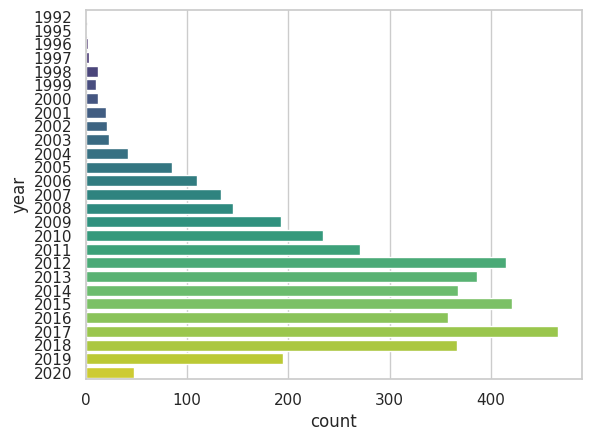

In [441]:
sns.countplot(y = 'year' , data = df  , palette='viridis')

<Axes: ylabel='selling_price'>

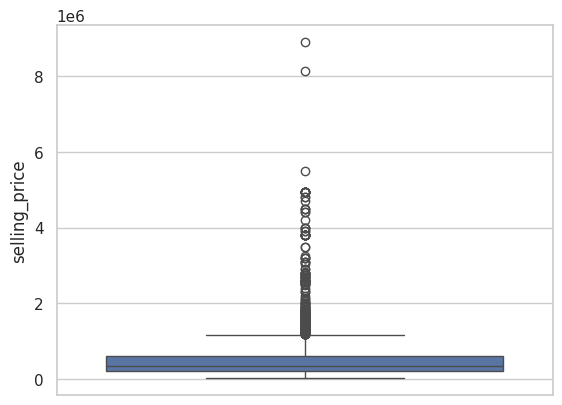

In [442]:
sns.boxplot(y = 'selling_price' , data = df)

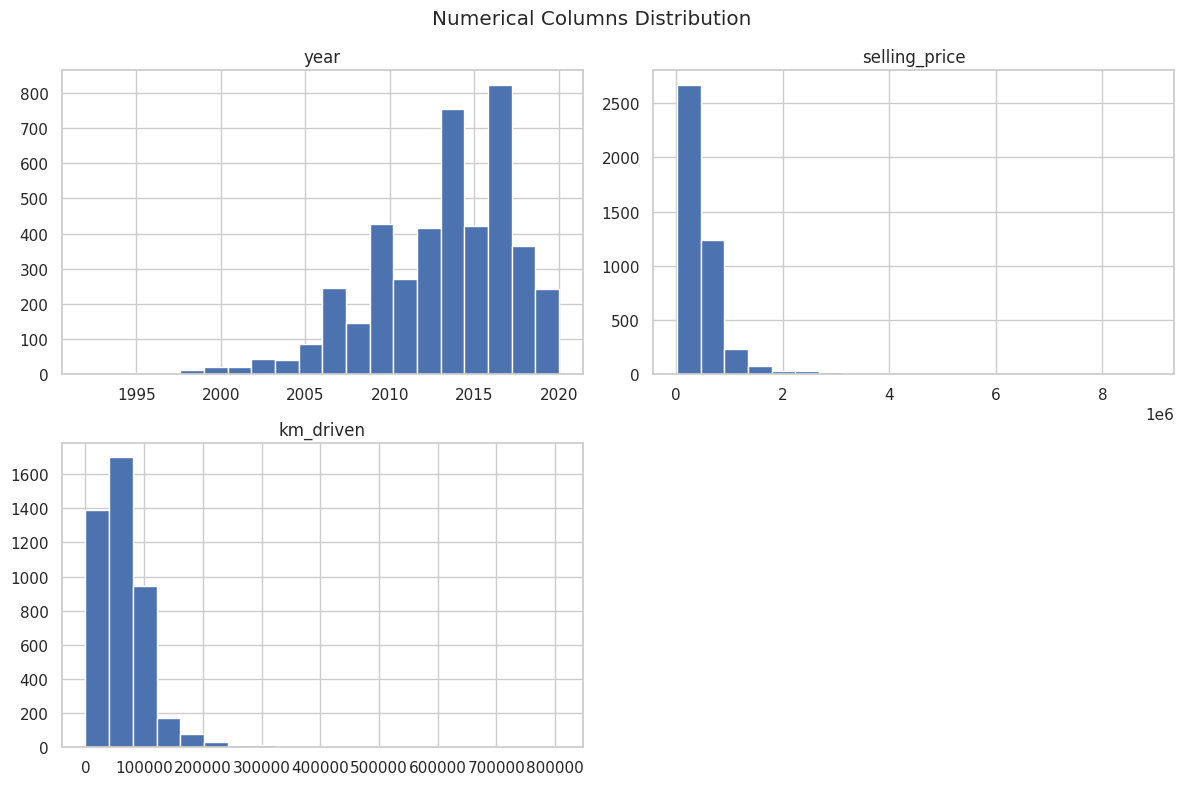

In [443]:
df.hist(figsize=(12, 8), bins=20)
plt.suptitle("Numerical Columns Distribution")
plt.tight_layout()
plt.show()

In [444]:
df.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner'],
      dtype='object')

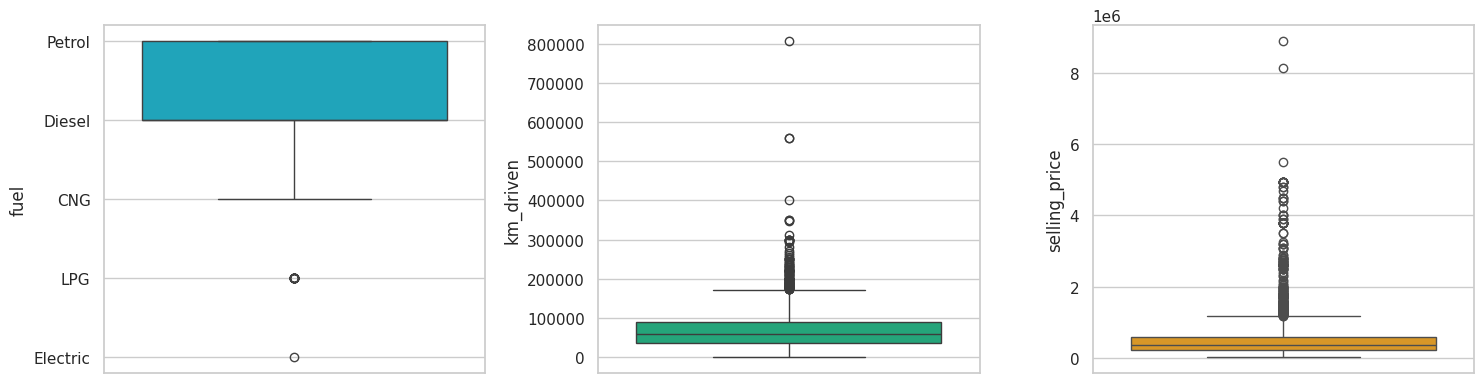

In [445]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(y=df['fuel'], ax=axes[0], color='#06B6D4')
sns.boxplot(y=df['km_driven'], ax=axes[1], color='#10B981')
sns.boxplot(y=df['selling_price'],ax=axes[2], color='#F59E0B')
plt.tight_layout(); plt.show()

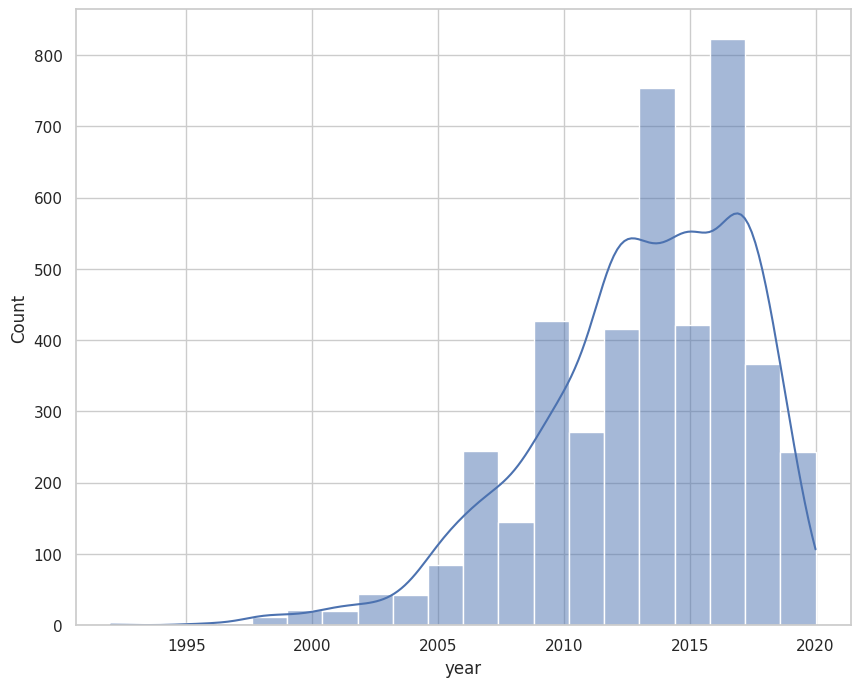

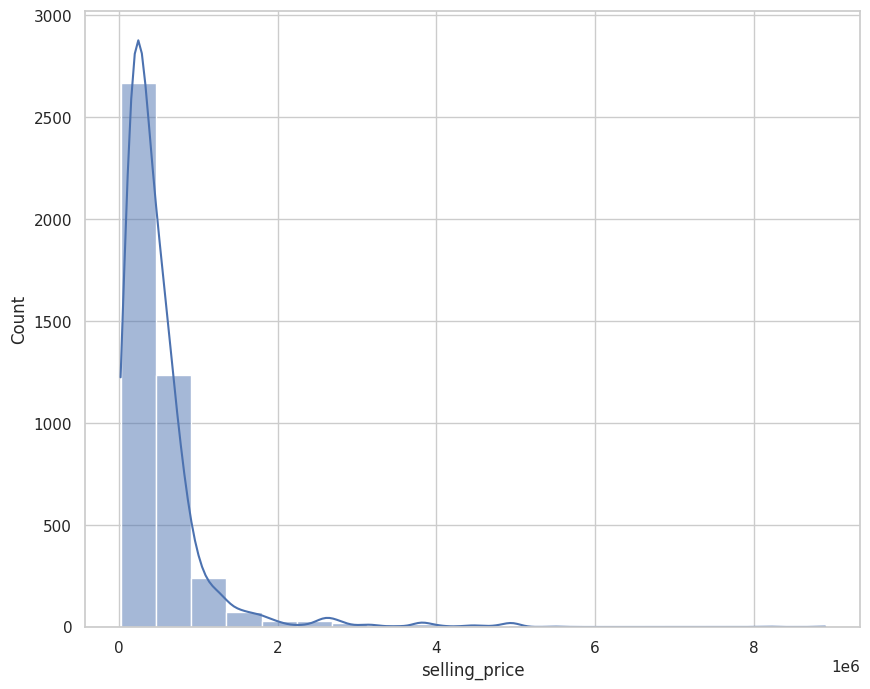

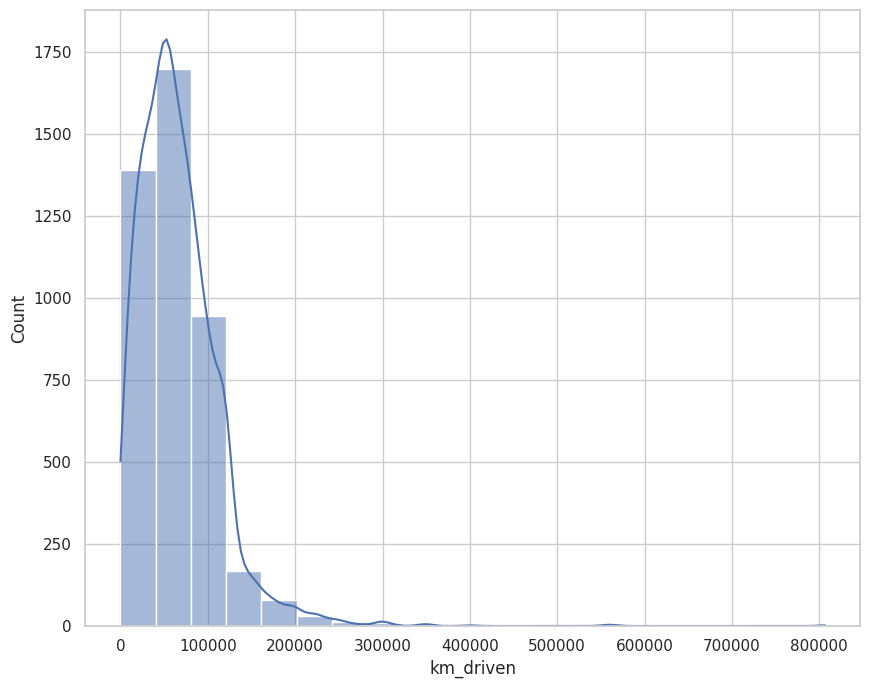

In [446]:
numeric_columns = ['year' , 'selling_price' , 'km_driven']
for col in numeric_columns:
  plt.figure(figsize=(10,8))
  sns.histplot(df[col] , kde = True , bins = 20)

<Axes: xlabel='transmission', ylabel='count'>

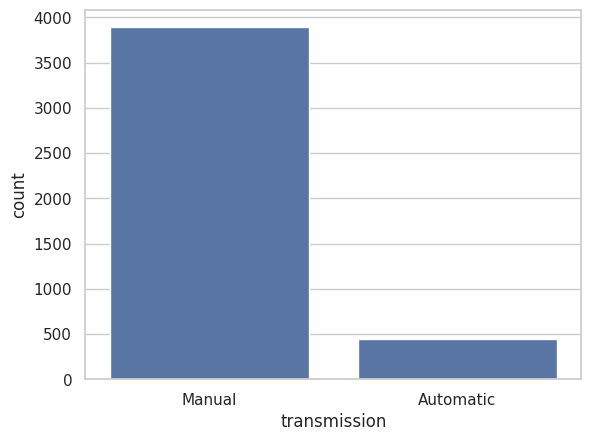

In [447]:
sns.countplot(x = df['transmission'])

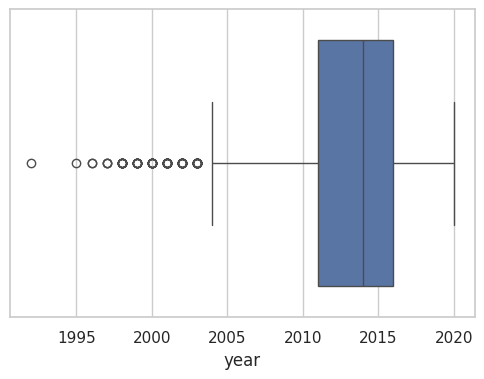

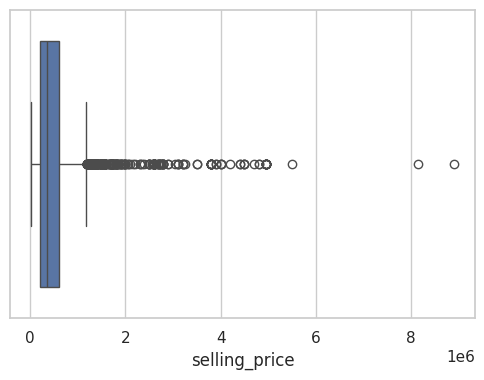

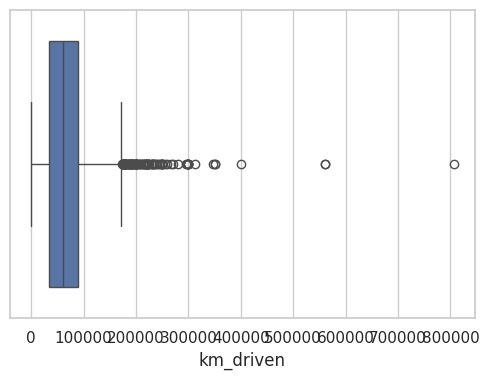

In [448]:
for col in numeric_columns:
  plt.figure(figsize=(6,4))
  sns.boxplot(x=df[col])

<Axes: >

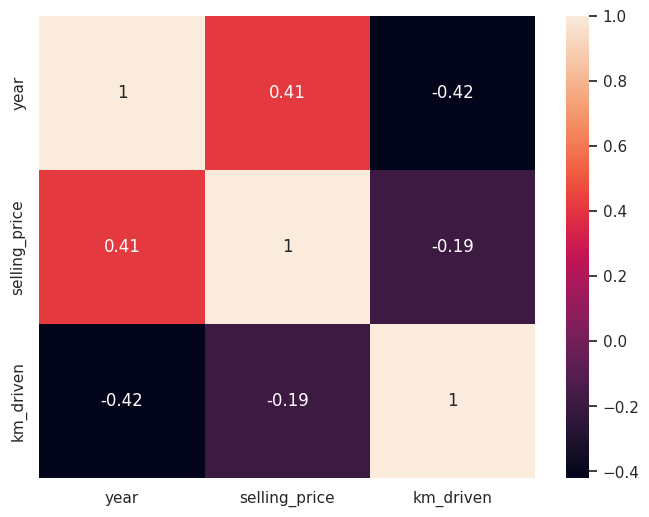

In [449]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True) , annot=True)

In [450]:
# check outlier of selling price

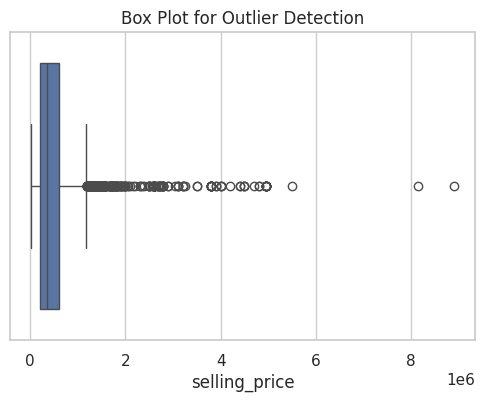

In [451]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['selling_price'])
plt.title('Box Plot for Outlier Detection')
plt.xlabel('selling_price')
plt.show()

In [452]:
# Found outlier for selling price .

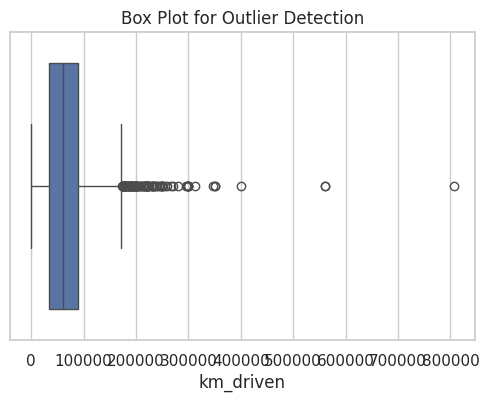

In [453]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['km_driven'])
plt.title('Box Plot for Outlier Detection')
plt.xlabel('km_driven')
plt.show()

In [454]:
# found outlier for km_driven .

# Data Cleaning

In [455]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [456]:
df.duplicated().sum()

np.int64(763)

In [457]:
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

In [458]:
df.duplicated().sum()

np.int64(0)

# Feature Engineering

In [459]:
original_price = df['selling_price'].copy()
original_km = df['km_driven'].copy()

In [460]:
# Removing outlier for selling_price
outlier = df['selling_price'].quantile(0.99)
df = df[df['selling_price'] < outlier]
df['selling_price'] = np.log1p(df['selling_price'])

In [461]:
# Removing outlier for km_driven
outlier = df['km_driven'].quantile(0.99)
df = df[df['km_driven'] < outlier]
df['km_driven'] = np.log1p(df['km_driven'])

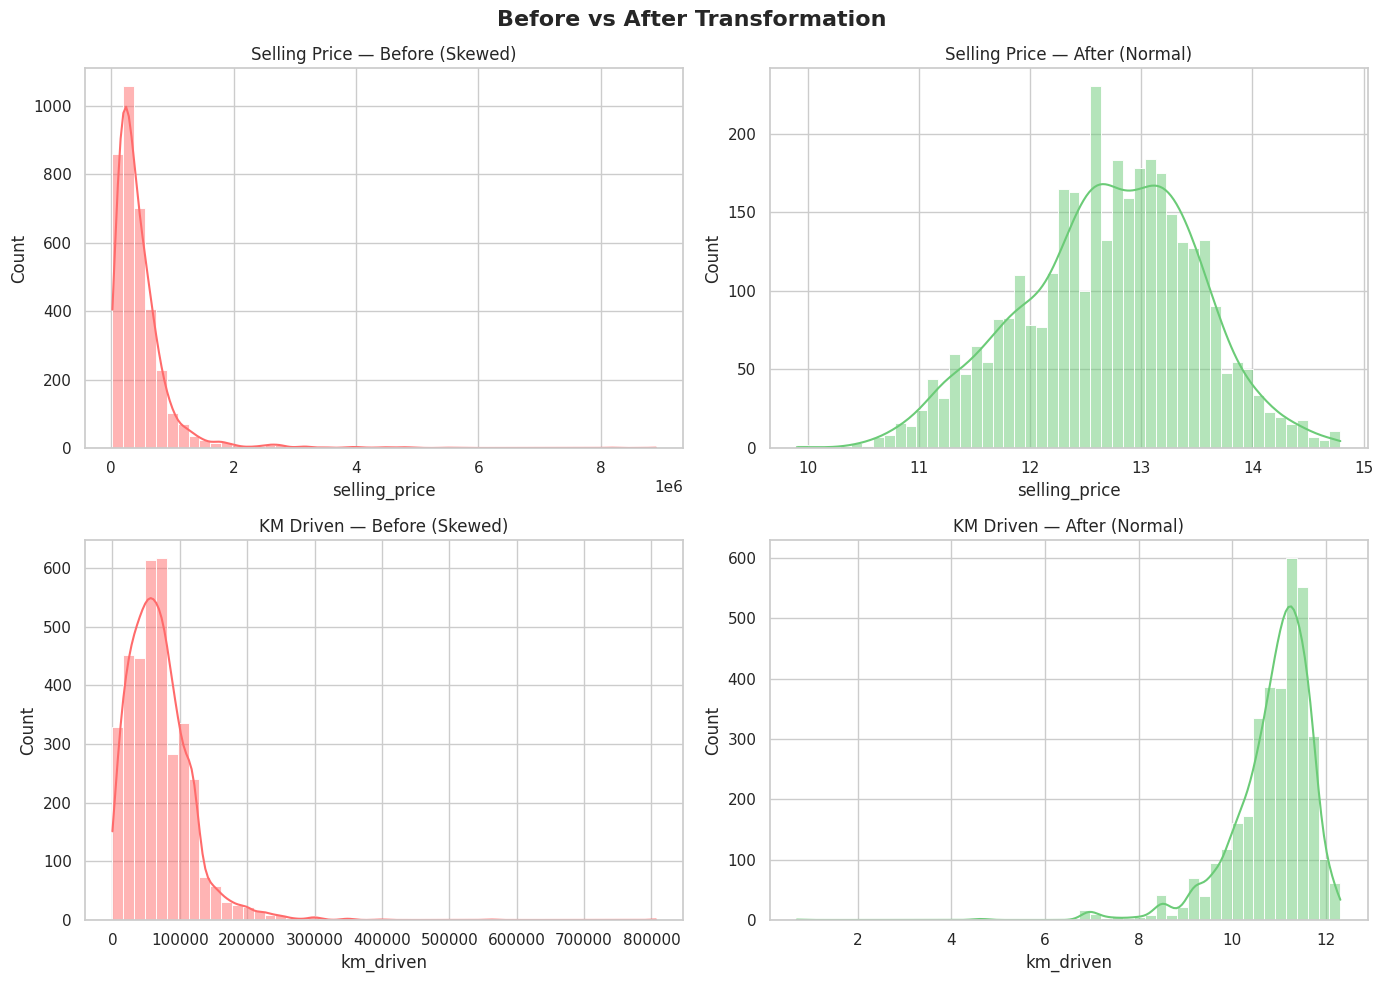

In [462]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Before vs After Transformation', fontsize=16, fontweight='bold')

# Selling Price Before
sns.histplot(original_price, bins=50, ax=axes[0][0],
             color='#FF6B6B', kde=True)
axes[0][0].set_title('Selling Price — Before (Skewed)')

# Selling Price After
sns.histplot(df['selling_price'], bins=50, ax=axes[0][1],
             color='#6BCB77', kde=True)
axes[0][1].set_title('Selling Price — After (Normal)')

# KM Driven Before
sns.histplot(original_km, bins=50, ax=axes[1][0],
             color='#FF6B6B', kde=True)
axes[1][0].set_title('KM Driven — Before (Skewed)')

# KM Driven After
sns.histplot(df['km_driven'], bins=50, ax=axes[1][1],
             color='#6BCB77', kde=True)
axes[1][1].set_title('KM Driven — After (Normal)')

plt.tight_layout()
plt.savefig('transformations.png', dpi=150, bbox_inches='tight')
plt.show()

In [463]:
# Now making new column of car_age , how old the car age is .
df['car_age'] = 2026 - df['year']

In [464]:
df = df.drop('year', axis=1)

# Feature Encoding

In [465]:
# transmission column encoding
df['transmission'] = df['transmission'].replace({'Manual': 0, 'Automatic': 1})

In [466]:
# Now cleaning the name column
df['name'] = df['name'].str.split().str[0]
df['name'] = df['name'].str.strip().str.title()
rare_brands = ['Mitsubishi', 'Jaguar', 'Land', 'Volvo', 'Ambassador',
               'Jeep', 'Opelcorsa', 'Mg', 'Force', 'Daewoo', 'Isuzu', 'Kia']
df['name'] = df['name'].replace(rare_brands, 'Other')

In [467]:
# NOw creating dummies for fuel, seller_type , owner , name
df_new = pd.get_dummies(df , columns = ['fuel', 'seller_type', 'owner', 'name'])

In [468]:
df_new.head()

,selling_price,km_driven,transmission,car_age,fuel_CNG,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Dealer,...,name_Mahindra,name_Maruti,name_Mercedes-Benz,name_Nissan,name_Other,name_Renault,name_Skoda,name_Tata,name_Toyota,name_Volkswagen
0,11.002117,11.156265,0,19,False,False,False,False,True,False,...,False,True,False,False,False,False,False,False,False,False
1,11.813037,10.819798,0,19,False,False,False,False,True,False,...,False,True,False,False,False,False,False,False,False,False
2,13.304687,11.512935,0,14,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,12.429220,10.736418,0,9,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
4,13.017005,11.856522,0,12,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [469]:
# Now converting bool into int
bool_cols = df_new.select_dtypes(include='bool').columns
df_new[bool_cols] = df_new[bool_cols].astype(int)

In [470]:
df_new.head()

,selling_price,km_driven,transmission,car_age,fuel_CNG,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Dealer,...,name_Mahindra,name_Maruti,name_Mercedes-Benz,name_Nissan,name_Other,name_Renault,name_Skoda,name_Tata,name_Toyota,name_Volkswagen
0,11.002117,11.156265,0,19,0,0,0,0,1,0,...,0,1,0,0,0,0,0,0,0,0
1,11.813037,10.819798,0,19,0,0,0,0,1,0,...,0,1,0,0,0,0,0,0,0,0
2,13.304687,11.512935,0,14,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,12.429220,10.736418,0,9,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,13.017005,11.856522,0,12,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


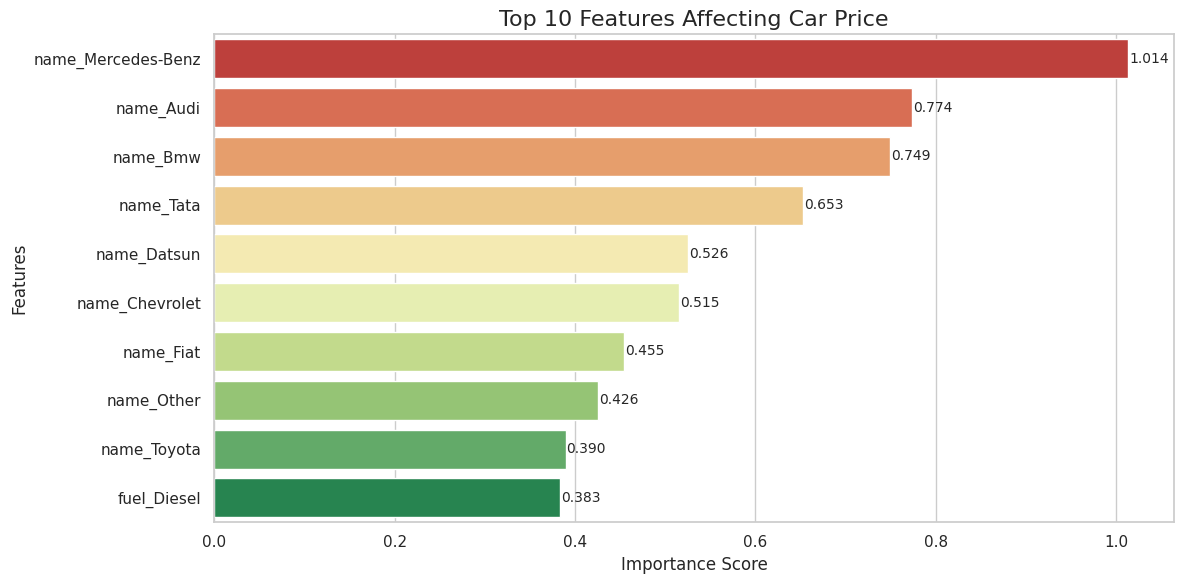

In [471]:
# Set plot style
sns.set_theme(style="whitegrid")

# Get feature importance from model coefficients
feature_importance = pd.Series(model.coef_, index=X.columns)

# Convert to absolute values and get top 10 features
feature_importance = feature_importance.abs()
feature_importance = feature_importance.sort_values(ascending=False)
feature_importance = feature_importance.head(10)

# Create figure
plt.figure(figsize=(12, 6))

# Create colors for bars
colors = sns.color_palette("RdYlGn", len(feature_importance))

# Create bar plot
ax = sns.barplot(
    x=feature_importance.values,
    y=feature_importance.index,
    palette=colors
)

# Add values on each bar
for i, value in enumerate(feature_importance.values):
    ax.text(
        value + 0.001,
        i,
        f"{value:.3f}",
        va="center",
        fontsize=10
    )

# Add title and labels
plt.title("Top 10 Features Affecting Car Price", fontsize=16)
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.savefig('feature_importance.png')
plt.tight_layout()
plt.show()

# Model Building

In [472]:
from sklearn.model_selection import train_test_split

In [473]:
X = df_new.drop('selling_price' , axis=1)
y = df_new['selling_price']

In [474]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

In [475]:
from sklearn.linear_model import LinearRegression

In [476]:
model = LinearRegression()
model.fit(X_train , y_train)

LinearRegression()

#  Model Evaluation

In [477]:
y_pred = model.predict(X_test)

In [478]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

n = X_test.shape[0]
p = X_test.shape[1]

adjusted_r2 = 1 - ((1 - r2) * (n - 1)  / (n - p - 1))

In [479]:
r2

0.7671139531199662

In [480]:
adjusted_r2

0.7552248756516161

# Model Save

In [481]:
import pickle

with open('car_price_model.pkl', 'wb') as file:
    pickle.dump(model, file)

In [482]:
from google.colab import files

files.download('car_price_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [488]:
feature_names = X.columns.tolist()

with open('feature_names.pkl', 'wb') as file:
    pickle.dump(feature_names, file)

# Model Architecture Visualization

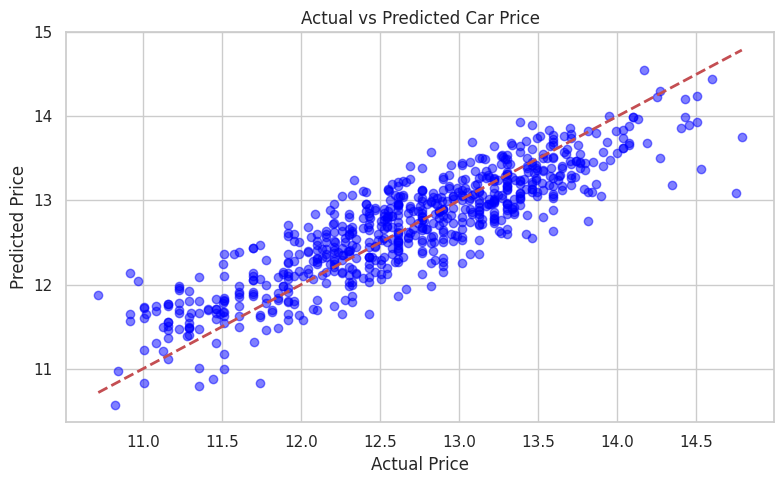

In [484]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Car Price')
plt.tight_layout()
#plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight
plt.savefig('actual_vs_predicted.png')
plt.show()

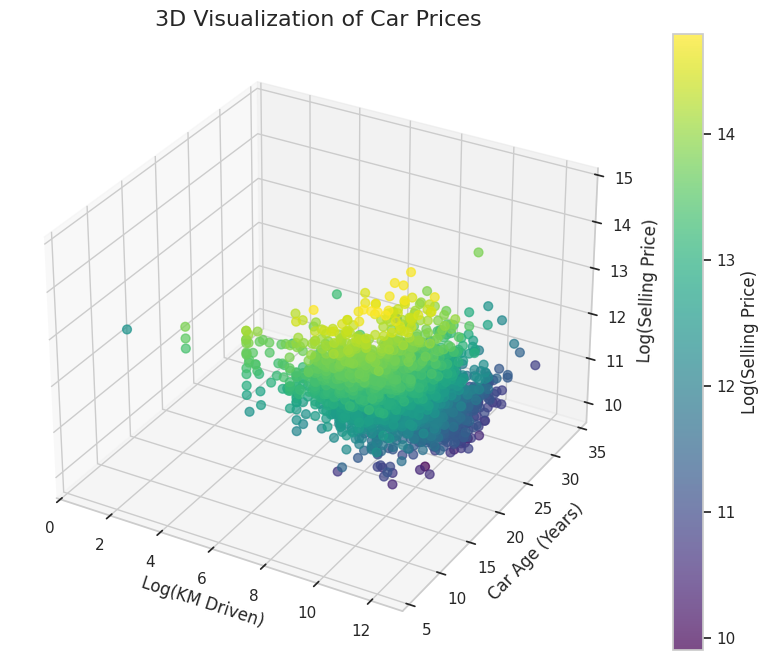

In [485]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df['km_driven'],
    df['car_age'],
    df['selling_price'],
    c=df['selling_price'],
    cmap='viridis',
    alpha=0.7,
    s=40
)

ax.set_title('3D Visualization of Car Prices', fontsize=16)

# Proper labels
ax.set_xlabel('Log(KM Driven)', fontsize=12)
ax.set_ylabel('Car Age (Years)', fontsize=12)
ax.set_zlabel('Log(Selling Price)', fontsize=12)

cbar = plt.colorbar(scatter)
cbar.set_label('Log(Selling Price)')
plt.savefig('3d_visualization.png')

plt.show()